<a href="https://colab.research.google.com/github/Sahil-Cod3r/Predictive-Analytics/blob/main/Walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Load the Walmart sales dataset
import pandas as pd

df = pd.read_csv('/content/sample_data/Walmart_Sales.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
# Check dataset shape, column names, data types, and missing values

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (6435, 8)

Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Data types:
 Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Missing values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [3]:
# Convert Date column from text to proper datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract Year, Month, and Week from Date to help the model capture seasonality
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

# Evaluate everything is correct
df[['Date', 'Year', 'Month', 'Week']].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


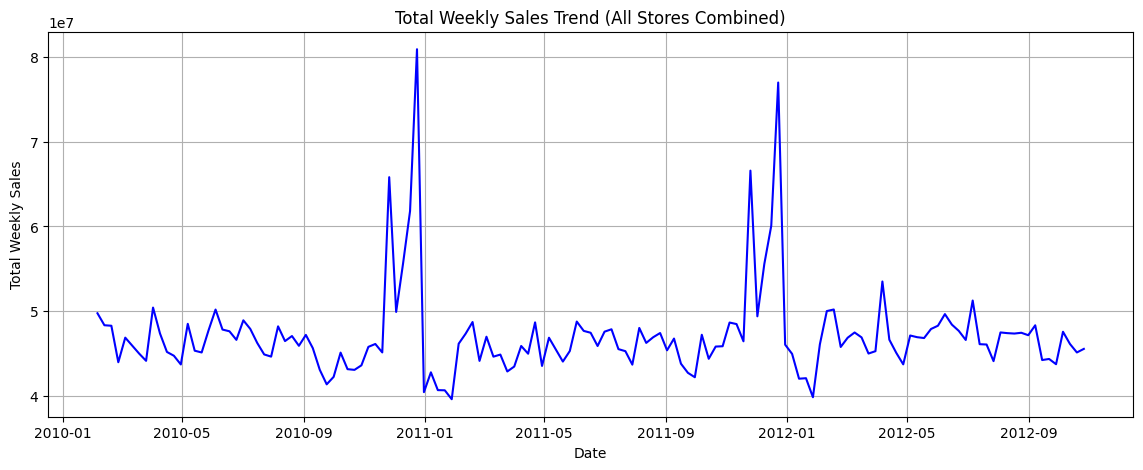

In [4]:
# Visualize total weekly sales trend across all stores to check seasonality

import matplotlib.pyplot as plt

weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], color='blue')
plt.title('Total Weekly Sales Trend (All Stores Combined)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.show()

In [6]:
# Model Building: Train two models to compare performance
# Linear Regression (baseline) and Random Forest Regressor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features and target
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']
X = df[features]
y = df['Weekly_Sales']

# Split data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on test set
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Model trained successfully!
Training samples: 5148
Testing samples: 1287


In [8]:
# Model Evaluation: check accuracy of Linear Regression using MAE, RMSE, R²

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE (Mean Absolute Error): 432594.98
RMSE (Root Mean Squared Error): 521583.50
R² Score: 0.1555


In [9]:
# Train Random Forest Regressor - handles non-linear relationships
# and categorical-like features (e.g., Store) better than Linear Regression

from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Results:
MAE: 62022.51
RMSE: 114106.34
R² Score: 0.9596


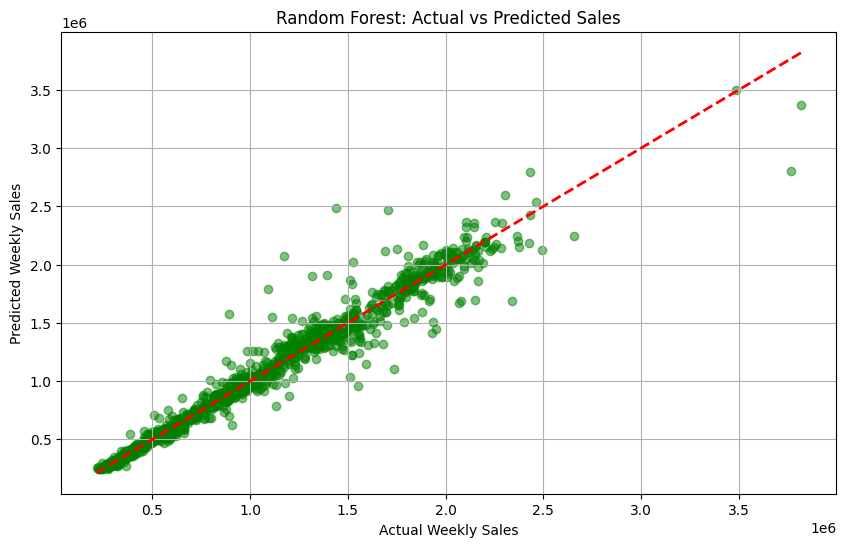

In [10]:
# Visualize predictions: compare actual vs predicted sales for Random Forest

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Random Forest: Actual vs Predicted Sales')
plt.grid(True)
plt.show()

        Feature  Importance
0         Store    0.663337
4           CPI    0.153930
5  Unemployment    0.104181
8          Week    0.050030
2   Temperature    0.012892
3    Fuel_Price    0.010295
7         Month    0.002867
1  Holiday_Flag    0.001594
6          Year    0.000874


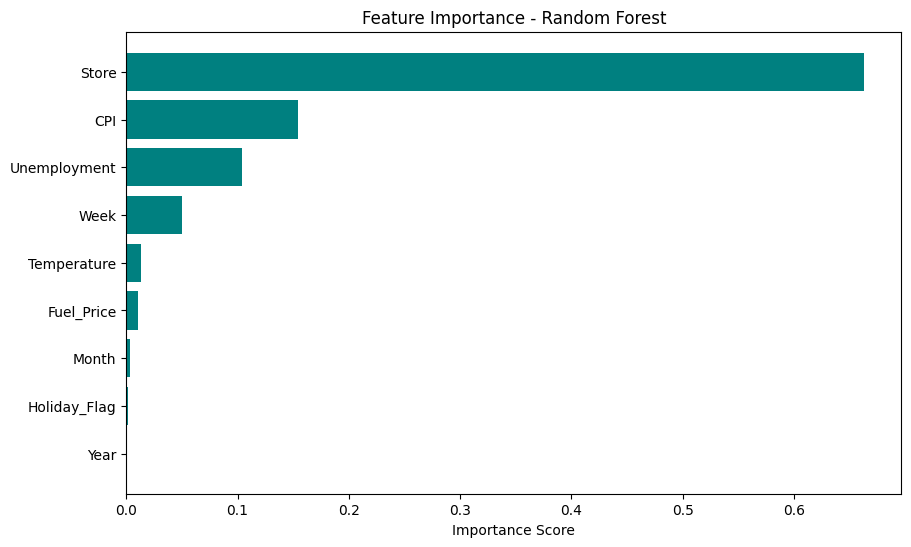

In [11]:
# Feature Importance: identify which factors most influence sales predictions

import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [13]:
# Generate forecast for Store 1, for the next 10 weeks
future_weeks = pd.DataFrame({
    'Store': [1]*10,
    'Holiday_Flag': [0]*10,
    'Temperature': [df['Temperature'].mean()]*10,
    'Fuel_Price': [df['Fuel_Price'].mean()]*10,
    'CPI': [df['CPI'].mean()]*10,
    'Unemployment': [df['Unemployment'].mean()]*10,
    'Year': [2013]*10,
    'Month': [1,1,2,2,3,3,4,4,5,5],
    'Week': list(range(1,11))
})

future_predictions = rf_model.predict(future_weeks)

for i, pred in enumerate(future_predictions, 1):
    print(f"Week {i}: Predicted Sales = ${pred:,.2f}")

Week 1: Predicted Sales = $1,840,441.68
Week 2: Predicted Sales = $1,825,469.47
Week 3: Predicted Sales = $1,935,399.86
Week 4: Predicted Sales = $1,932,093.37
Week 5: Predicted Sales = $2,024,746.93
Week 6: Predicted Sales = $2,027,788.92
Week 7: Predicted Sales = $1,983,016.41
Week 8: Predicted Sales = $1,945,967.64
Week 9: Predicted Sales = $1,948,511.90
Week 10: Predicted Sales = $1,934,929.51


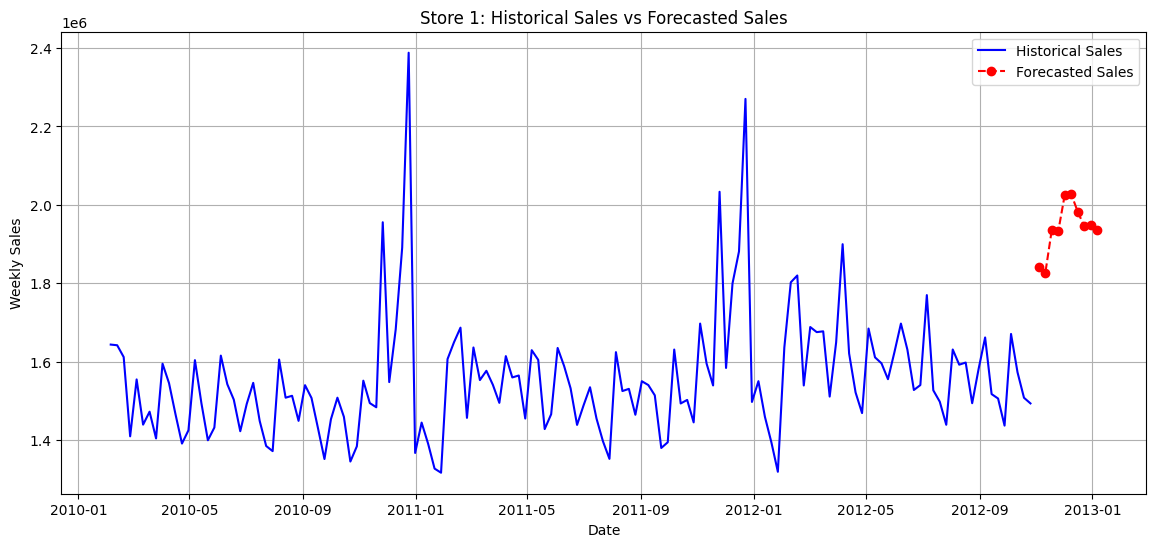

In [14]:
# Get historical sales for Store 1 only
store1_data = df[df['Store'] == 1].sort_values('Date')

# Create future dates for plotting (weekly, starting after last known date)
last_date = store1_data['Date'].max()
future_dates = pd.date_range(start=last_date, periods=11, freq='W')[1:]

plt.figure(figsize=(14,6))

# Plot historical sales
plt.plot(store1_data['Date'], store1_data['Weekly_Sales'], label='Historical Sales', color='blue')

# Plot future predictions
plt.plot(future_dates, future_predictions, label='Forecasted Sales', color='red', linestyle='--', marker='o')

plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Store 1: Historical Sales vs Forecasted Sales')
plt.legend()
plt.grid(True)
plt.show()
